# Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Data

In [2]:
df = pd.read_csv(r"C:\Users\siddh\Downloads\titanic\train.csv")

# Understand the Dataset

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.shape

(891, 12)

In [56]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


df.describe()

In [11]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [24]:
print(df['Age'].dtype)

float64


In [25]:
# Convert Age to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          0 non-null      float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Data Cleaning

In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
df.isnull().sum().sum()

np.int64(866)

In [18]:
(df.isnull().sum()/df.shape[0])*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [19]:
df.notnull().sum()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [28]:
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])

In [30]:
print(df['Cabin'].isnull().sum())

0


In [34]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [51]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df.dropna(inplace=True)

# Exploratory Data Analysis

In [57]:
df['Fare'].value_counts()

Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
35.0000     1
28.5000     1
6.2375      1
14.0000     1
10.5167     1
Name: count, Length: 248, dtype: int64

In [58]:
df['Fare'].mean()

np.float64(32.204207968574636)

In [59]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [61]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [62]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

# Data Visulazation

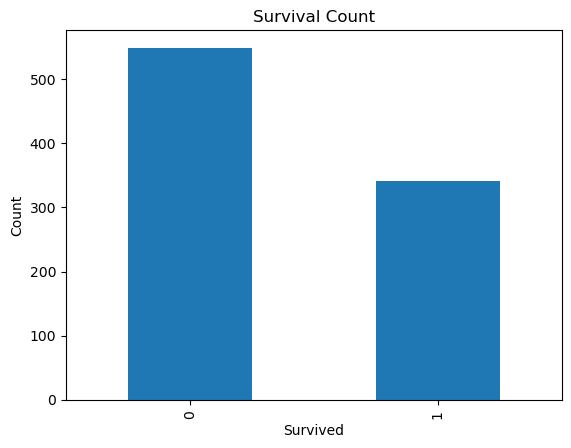

In [63]:
df['Survived'].value_counts().plot(kind='bar')

plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

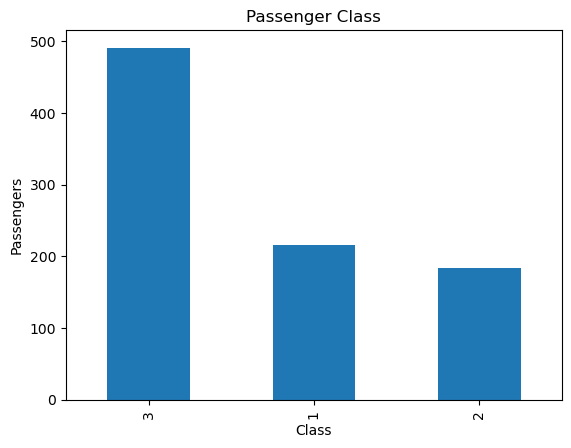

In [64]:
df['Pclass'].value_counts().plot(kind='bar')

plt.title('Passenger Class')
plt.xlabel('Class')
plt.ylabel('Passengers')
plt.show()

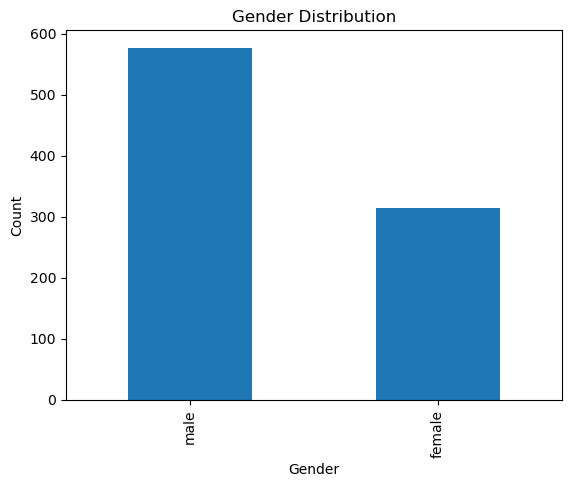

In [65]:
df['Sex'].value_counts().plot(kind='bar')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

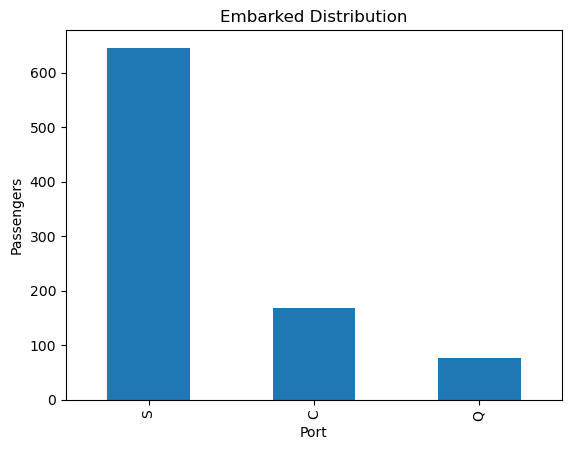

In [66]:
df['Embarked'].value_counts().plot(kind='bar')

plt.title('Embarked Distribution')
plt.xlabel('Port')
plt.ylabel('Passengers')
plt.show()

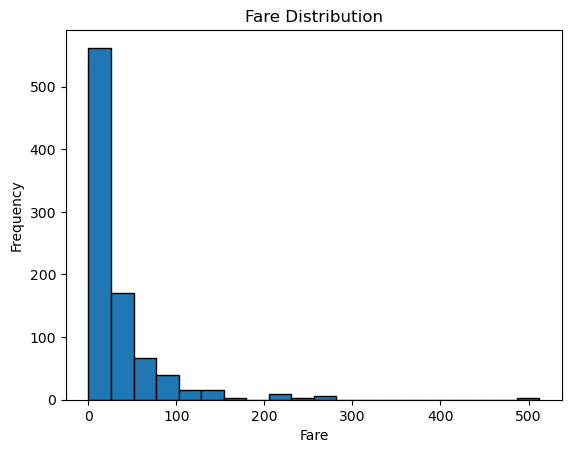

In [68]:
df['Fare'].plot(kind='hist', bins=20, edgecolor='black')

plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

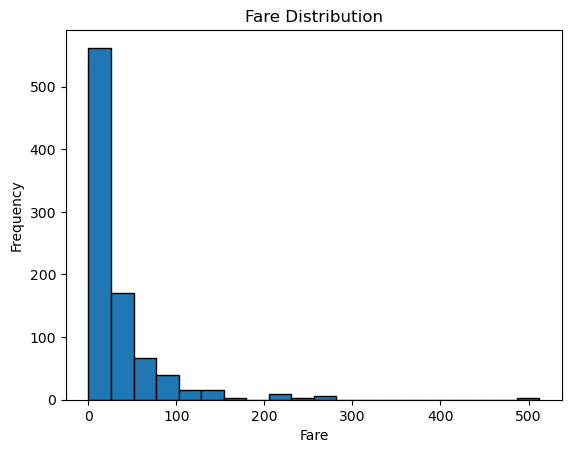

In [70]:
df['Fare'].plot(kind='hist', bins=20, edgecolor='black')

plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

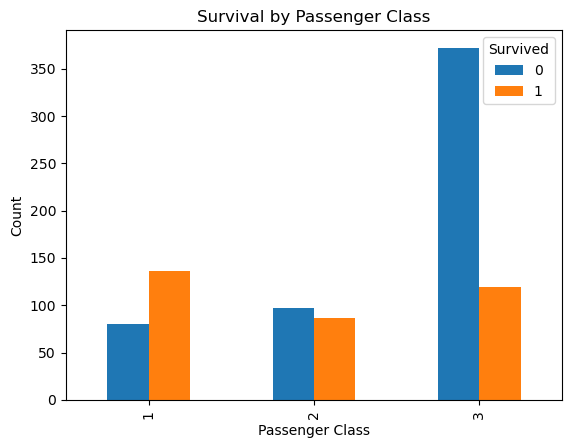

In [71]:
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

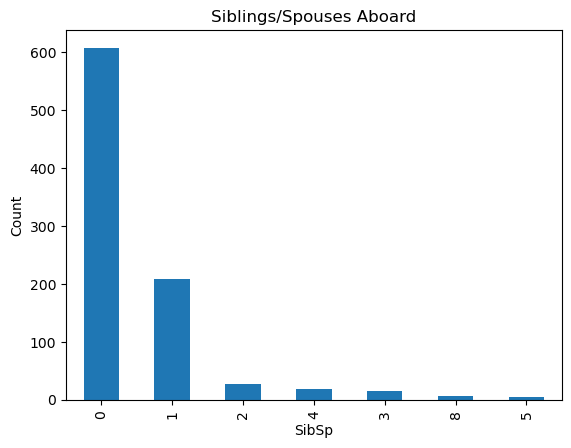

In [72]:
df['SibSp'].value_counts().plot(kind='bar')

plt.title('Siblings/Spouses Aboard')
plt.xlabel('SibSp')
plt.ylabel('Count')
plt.show()

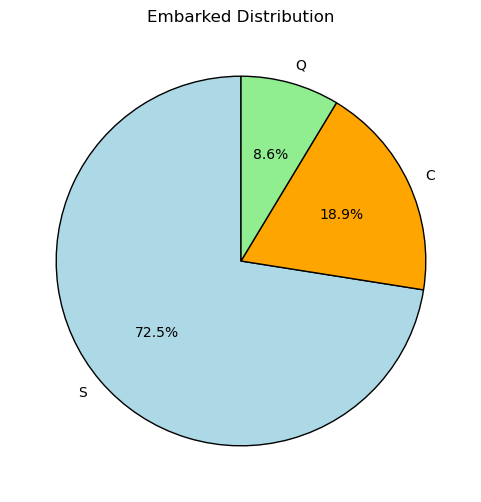

In [73]:
plt.figure(figsize=(6,6))

df['Embarked'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightblue', 'orange', 'lightgreen'],
    wedgeprops={'edgecolor':'black'}
)

plt.title('Embarked Distribution')
plt.ylabel('')
plt.show()

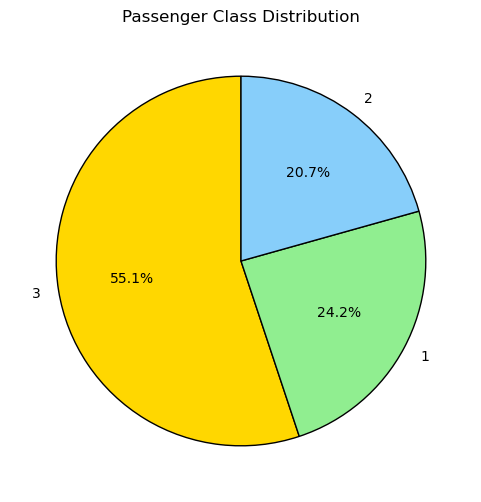

In [74]:
plt.figure(figsize=(6,6))

df['Pclass'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['gold', 'lightgreen', 'lightskyblue'],
    wedgeprops={'edgecolor':'black'}
)

plt.title('Passenger Class Distribution')
plt.ylabel('')
plt.show()

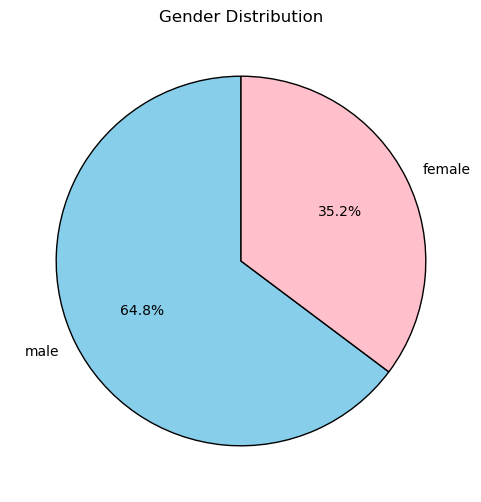

In [75]:
plt.figure(figsize=(6,6))

df['Sex'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'pink'],
    wedgeprops={'edgecolor':'black'}
)

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

In [77]:
import squarify

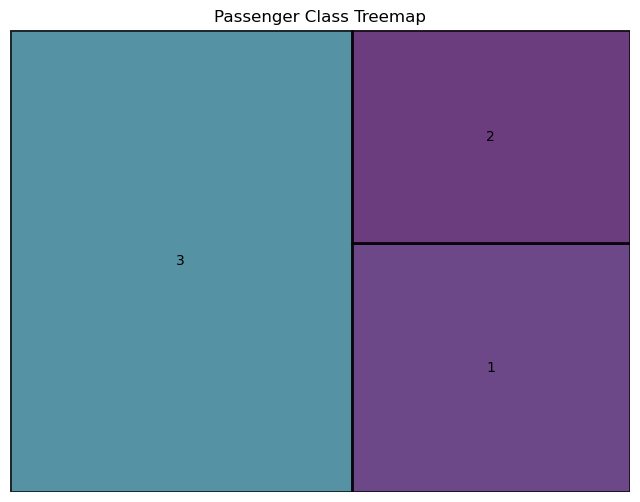

In [78]:
sizes = df['Pclass'].value_counts()
labels = sizes.index.astype(str)

plt.figure(figsize=(8,6))

squarify.plot(
    sizes=sizes,
    label=labels,
    alpha=0.8,
    edgecolor='black',
    linewidth=2
)

plt.title("Passenger Class Treemap")
plt.axis('off')
plt.show()

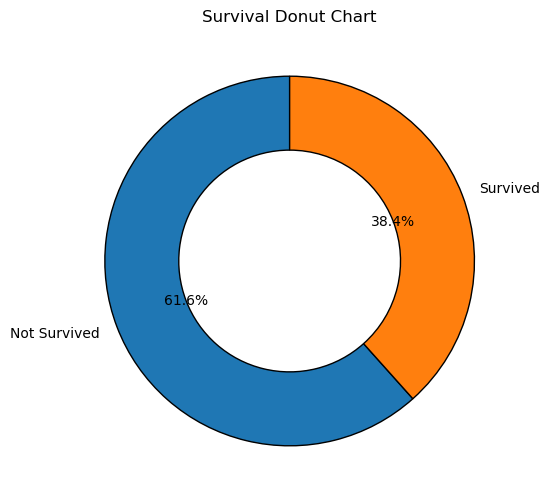

In [81]:
plt.figure(figsize=(6,6))

plt.pie(
    df['Survived'].value_counts(),
    labels=['Not Survived','Survived'],
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.4, edgecolor='black'),
    startangle=90
)

plt.title("Survival Donut Chart")
plt.show()

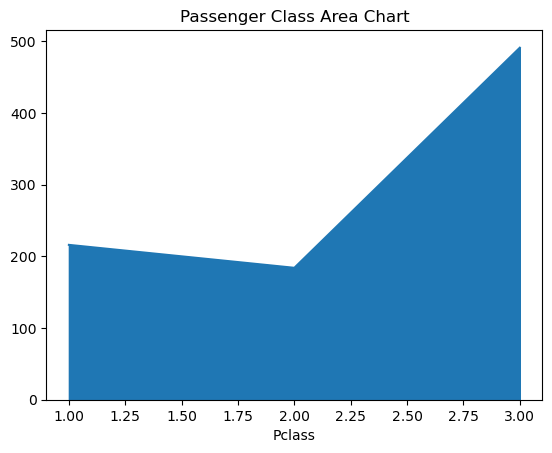

In [85]:
df['Pclass'].value_counts().sort_index().plot(kind='area')

plt.title("Passenger Class Area Chart")
plt.show()

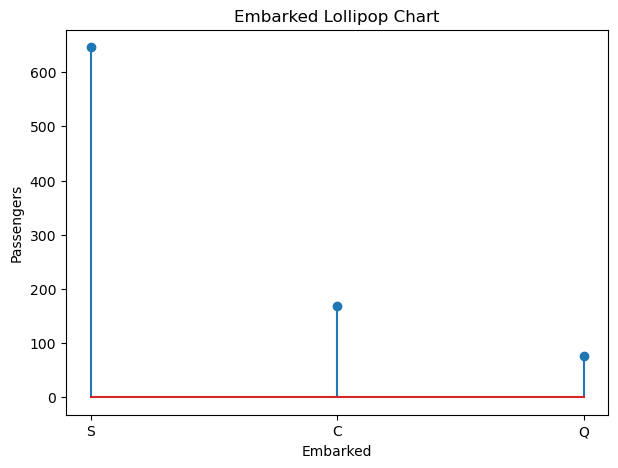

In [86]:
counts = df['Embarked'].value_counts()

plt.figure(figsize=(7,5))

plt.stem(counts.index, counts.values)

plt.title("Embarked Lollipop Chart")
plt.xlabel("Embarked")
plt.ylabel("Passengers")
plt.show()

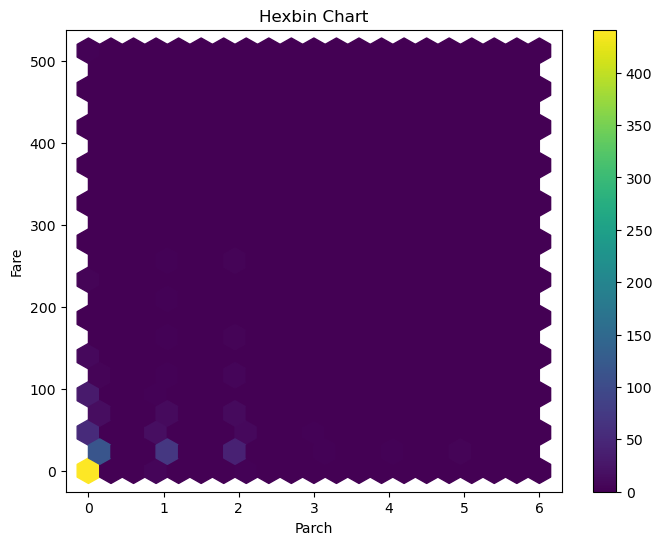

In [89]:
plt.figure(figsize=(8,6))

plt.hexbin(df['Parch'], df['Fare'], gridsize=20)

plt.xlabel("Parch")
plt.ylabel("Fare")
plt.title("Hexbin Chart")
plt.colorbar()
plt.show()

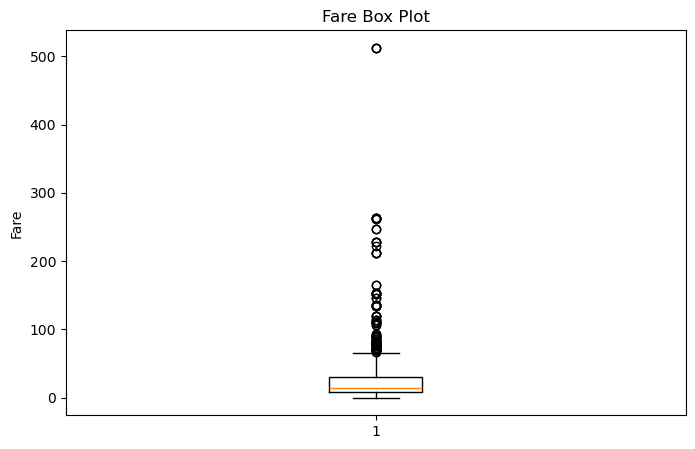

In [90]:
plt.figure(figsize=(8,5))

plt.boxplot(df['Fare'])

plt.title("Fare Box Plot")
plt.ylabel("Fare")
plt.show()

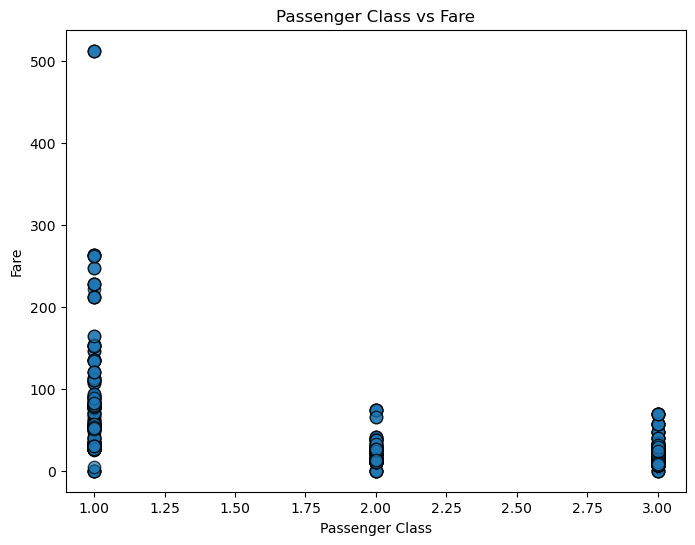

In [93]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Pclass'],
    df['Fare'],
    s=80,
    edgecolors='black',
    alpha=0.7
)

plt.title("Passenger Class vs Fare")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

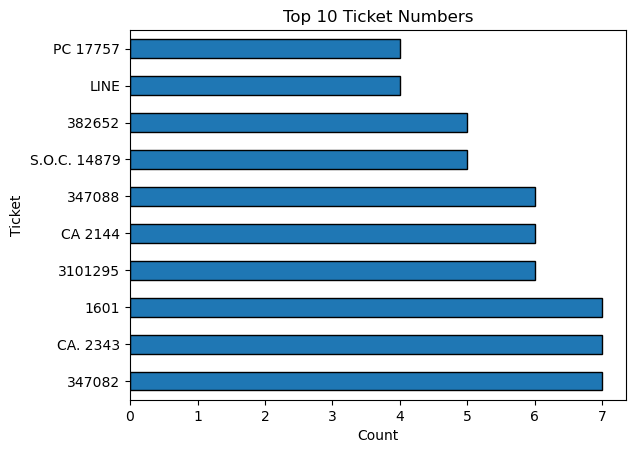

In [95]:
df['Ticket'].value_counts().head(10).plot(
    kind='barh',
    edgecolor='black'
)

plt.title("Top 10 Ticket Numbers")
plt.xlabel("Count")
plt.show()

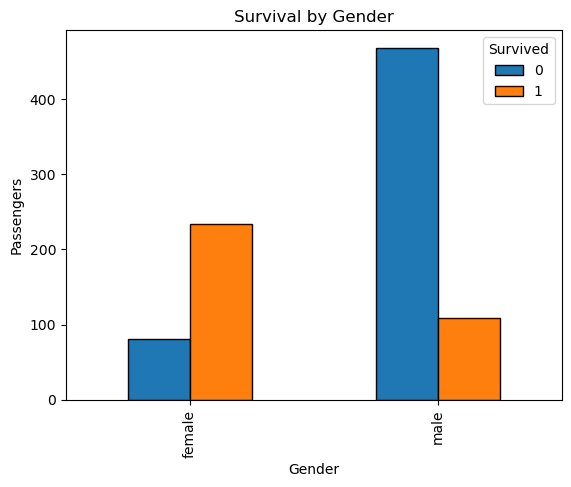

In [96]:
pd.crosstab(df['Sex'], df['Survived']).plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Passengers")
plt.show()

<Figure size 800x500 with 0 Axes>

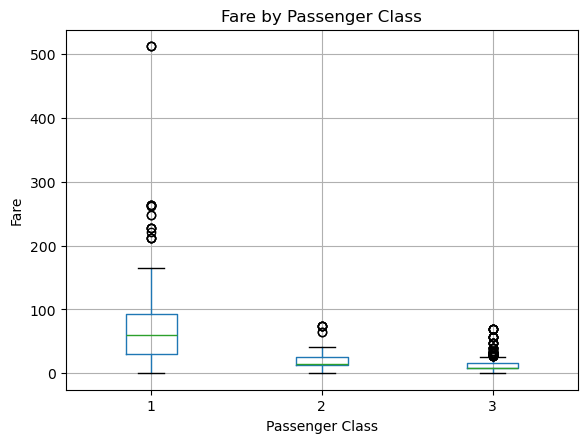

In [97]:
plt.figure(figsize=(8,5))

df.boxplot(column='Fare', by='Pclass')

plt.title("Fare by Passenger Class")
plt.suptitle('')
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()